In [ ]:
import torch
import torch.nn as nn

### Что делает nn.Embedding?


Перевод слова embedding - встраиваение. Взаимосвязь можно описать так: слой nn.Embedding “встраивает” (вкладывает) дискретные объекты в непрерывное векторное пространство, поэтому и называется встраиванием (embedding).

Это слой, который преобразует дискретные индексы (слова, токены, символы) в векторные представления фиксированной размерности.

То есть nn.Embedding по сути является таблицей (lookup table), которая хранит обучаемые векторы (признаки по горизонтали этот слой формирует самостоятельно):

<img src='https://www.scaler.com/topics/images/word-embedding-example.webp'>

**[Таблица поиска (англ. lookup table)](https://ru.wikipedia.org/wiki/%D0%A2%D0%B0%D0%B1%D0%BB%D0%B8%D1%86%D0%B0_%D0%BF%D0%BE%D0%B8%D1%81%D0%BA%D0%B0)** — это структура данных, в которой хранятся результаты интерполяции функции. Обычно это массив или ассоциативный массив, используемый с целью заменить вычисления на операцию простого поиска. Увеличение скорости может быть значительным, так как получить данные из памяти зачастую быстрее, чем выполнить трудоёмкие вычисления.

Рассмотрим на примере, ниже дана таблица и результат обращения по индексу словаря, в данном случае 1:

In [ ]:
table = {
    0: [0.1, -0.3, 0.8],
    1: [-1.2, 0.4, 0.0],
    2: [0.9, 0.7, -0.6]
}

table[1]

[-1.2, 0.4, 0.0]

На данном этапе воспринимаем слой встраивания `nn.Embedding` как lookup table, в которой каждая строка содержит в себе вектор признаков, и происходит обращение к данной строке по индексу.

Разберём подробнее [пример из документации](https://docs.pytorch.org/docs/stable/generated/torch.nn.Embedding.html): пусть слой встраивания `nn.Embedding` будет содержать 10 векторов (тензоров в контексте работы на pytorch) размерности 3 каждый:

In [ ]:
# an Embedding module containing 10 tensors of size 3
embedding = torch.nn.Embedding(10, 3)

Посмотрим на матрицу, которой представлен этот слой. Для этого обратимся через параметр, отвечающий за веса:

In [ ]:
print(embedding.weight)

Parameter containing:
tensor([[ 0.1820,  0.4024,  0.4508],
        [ 1.1908, -0.7430,  0.1512],
        [ 0.1056, -0.6680,  0.8777],
        [ 0.1846, -0.1094,  0.5665],
        [-2.4939,  1.3217, -0.4736],
        [-1.6859, -1.2061, -0.9808],
        [ 1.4909, -1.1841, -0.1261],
        [ 0.2102, -1.4014, -0.4148],
        [ 0.3656,  0.6772, -0.4351],
        [ 0.5667,  1.5165,  0.4132]], requires_grad=True)


Теперь узнаем, как этот слой будет обрабатывать входные последовательности индексов. Обращаем внимание на то, что слой `nn.Embedding` работает не со словами или токенами, а с их индексами. Его задача переводить индексы слов в числовые представления, пригодные для дальнейшей подачи в рекуррентные нейронные сети (RNN).

Создадим партию данных (batch) из двух примеров, каждый из которых будет содержать по 4 индекса. Аналог: есть 2 предложения, каждое из которых содержит по 4 слова, закодированные индексами.

In [ ]:
# a batch of 2 samples of 4 indices each
input = torch.LongTensor([[1, 2, 4, 5], [4, 3, 2, 9]])
embedding(input)

tensor([[[ 1.1908, -0.7430,  0.1512],
         [ 0.1056, -0.6680,  0.8777],
         [-2.4939,  1.3217, -0.4736],
         [-1.6859, -1.2061, -0.9808]],

        [[-2.4939,  1.3217, -0.4736],
         [ 0.1846, -0.1094,  0.5665],
         [ 0.1056, -0.6680,  0.8777],
         [ 0.5667,  1.5165,  0.4132]]], grad_fn=<EmbeddingBackward0>)

Как мы видим, слой встраивания `nn.Embedding` сопоставил каждому предложению матрицу из векторов, отвечающих каждому индексу:

```
Parameter containing:
tensor([  0 - [ 0.1820,  0.4024,  0.4508],
          1 - [ 1.1908, -0.7430,  0.1512],
          2 - [ 0.1056, -0.6680,  0.8777],
          3 - [ 0.1846, -0.1094,  0.5665],
          4 - [-2.4939,  1.3217, -0.4736],
          5 - [-1.6859, -1.2061, -0.9808],
          6 - [ 1.4909, -1.1841, -0.1261],
          7 - [ 0.2102, -1.4014, -0.4148],
          8 - [ 0.3656,  0.6772, -0.4351],
          9 - [ 0.5667,  1.5165,  0.4132]], requires_grad=True)
```
Соответственно, первому предложению $[1, 2, 4, 5]$ будет соответствовать матрица

```
tensor([  1 - [ 1.1908, -0.7430,  0.1512],
          2 - [ 0.1056, -0.6680,  0.8777],
          4 - [-2.4939,  1.3217, -0.4736],
          5 - [-1.6859, -1.2061, -0.9808], requires_grad=True)
```

Обратим внимание на параметр `requires_grad=True`, действительно в нашем случае он показывает `True`, а значит, это обучаемый параметр.

In [ ]:
embedding.weight.requires_grad

True

Таким образом, `nn.Embedding` - это обучаемая таблица векторов, которая переводит индексы слов в числовые представления, пригодные для подачи в дальнейшую модель.

Другими словами, nn.Embedding - это динамический способ хранения векторов (которые ассоциированы с данными), который подстраивается под модель с каждым циклом обучения.

Аналогию из жизни можно привести как книжные полки (слой встраивания), с которых читатель (модель) может брать книги и переписывать в зависимости от того, что ему говорит функция потерь.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

torch.manual_seed(42)

vocab_size = 6
embedding_dim = 4

embedding = nn.Embedding(vocab_size, embedding_dim)

optimizer = optim.SGD(embedding.parameters(), lr=0.1)

print("Embedding BEFORE training:\n")
print(embedding.weight.data)

input_indices = torch.tensor([1, 3, 4])

emb = embedding(input_indices)

loss = emb.sum()

optimizer.zero_grad()
loss.backward()
optimizer.step()

print("\nEmbedding AFTER training:\n")
print(embedding.weight.data)


Embedding BEFORE training:

tensor([[ 1.9269,  1.4873,  0.9007, -2.1055],
        [ 0.6784, -1.2345, -0.0431, -1.6047],
        [ 0.3559, -0.6866, -0.4934,  0.2415],
        [-1.1109,  0.0915, -2.3169, -0.2168],
        [-0.3097, -0.3957,  0.8034, -0.6216],
        [-0.5920, -0.0631, -0.8286,  0.3309]])

Embedding AFTER training:

tensor([[ 1.9269,  1.4873,  0.9007, -2.1055],
        [ 0.5784, -1.3345, -0.1431, -1.7047],
        [ 0.3559, -0.6866, -0.4934,  0.2415],
        [-1.2109, -0.0085, -2.4169, -0.3168],
        [-0.4097, -0.4957,  0.7034, -0.7216],
        [-0.5920, -0.0631, -0.8286,  0.3309]])


Обращаем внимание на строки с индексами [1, 3, 4] - как видим, они изменились, в то время как строки с индексами [0, 2, 5] остались неизменными. Это одна из иллюстраций названия "встраивание":

Embedding BEFORE training:
```
tensor([ 0 -  [ 1.9269,  1.4873,  0.9007, -2.1055],
         1 - *[ 0.6784, -1.2345, -0.0431, -1.6047]*,
         2 -  [ 0.3559, -0.6866, -0.4934,  0.2415],
         3 - *[-1.1109,  0.0915, -2.3169, -0.2168]*,
         4 - *[-0.3097, -0.3957,  0.8034, -0.6216]*,
         5 -  [-0.5920, -0.0631, -0.8286,  0.3309]])
```
Embedding AFTER training:
```
tensor([ 0 -  [ 1.9269,  1.4873,  0.9007, -2.1055],
         1 - *[ 0.5784, -1.3345, -0.1431, -1.7047]*,
         2 -  [ 0.3559, -0.6866, -0.4934,  0.2415],
         3 - *[-1.2109, -0.0085, -2.4169, -0.3168]*,
         4 - *[-0.4097, -0.4957,  0.7034, -0.7216]*,
         5 -  [-0.5920, -0.0631, -0.8286,  0.3309]])
```

Обращаем внимание, что `nn.Embedding` обучается так, чтобы слова располагались в векторном пространстве по смыслу. Но он делает это не сам по себе.
Этот слой
- не знает, что такое смысл,
- не видит контекст целиком,
- не связывает слова напрямую.

Он только хранит обучаемые векторы, которые обновляются через общую модель и функцию потерь.

Разберём пример одного цикла обучения модели, содержащей слой встраивания nn.Embedding и два полносвязных слоя nn.Linear:

Для начала установим библиотеку torchviz для визуализации графа вычислений.

In [ ]:
!pip install torchviz

In [ ]:
class SimpleModel(nn.Module):
    def __init__(self, vocab_size=10, embedding_dim=4, hidden_dim=8):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.linear = nn.Linear(embedding_dim, hidden_dim)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x = self.embedding(x)
        x = x.mean(dim=1)
        x = self.linear(x)
        x = self.fc(x)
        return x

In [ ]:
model = SimpleModel()
x = torch.tensor([[1, 2, 3], [4, 5, 6]], dtype=torch.long)
output = model(x)

In [ ]:
output

tensor([[0.0776],
        [0.3976]], grad_fn=<AddmmBackward0>)

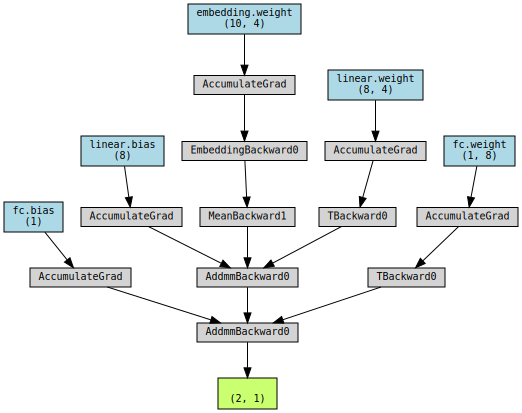

In [ ]:
from torchviz import make_dot
dot = make_dot(output,params=dict(model.named_parameters()))
dot


На графе вычислений явно видно, что слой nn.Embedding обучается (инициализация весов при создании слоя происходит случайным образом). Во время обучения градиенты от ошибки работы модели, например, перевода с одного языка на другой, проходят через линейные слои, доходят до входа, представленного слоем nn.Embedding и векторы слов корректируются.
В итоге похожие по смыслу слова (закодированные индексами) получают похожие векторы - нужные для перевода слова располагаются близко.

Вопрос: почему в pytorch реализован слой встраивания nn.Embedding? Почему его нельзя было просто заменить линейным слоем nn.Linear?

# Embedding vs Linear

Итак, по графу вычсилений мы увидели, что Embedding будет первым обучаемым узлом, который принимает LongTensor, имеет параметр embedding.weight, который участвует в алгоритме обратного распространения ошибки именно как параметр.
Итого:
- embedding.weight — отдельный параметр
- нет матричного умножения входных данных на embedding.weight
- используется EmbeddingBackward, а не AddmmBackward (умножение матриц и добавление к ним вектора сдвига)

Это отличает embedding от Linear.

Embedding:
- обновляет только используемые слова
- стабильно сходится
- хорошо масштабируется

Linear + one-hot:
- обновляет всё
- нестабильнее
- не используется на практике

Embedding-слой не переводит слова в признаки по смыслу. Он хранит векторы признаков для слов и отдаёт нужный вектор по индексу.
Смысл появляется позже — из-за обучения всей модели.

`nn.Embedding(V, d)` хранит матрицу $W \in R^{V \times d}$ и выполняет операцию: $Embedding(k)=W[k]$
То есть это операция сопоставления (lookup), а не вычисление, где вход — индекс (категория), а выход — строка таблицы.

`nn.Linear(V, d)` вычисляет: $y=xW+b$, где $x \in R^V$ - вектор признаков, $W \in R^{V \times d}$. `nn.Linear` ожидает числовые признаки, а не категорию. Если подать в линейный слой категориальные признаки, то признаки с большим номером, как правило, получат большие веса и модель будет обращать внимание в первую очередь на них.

Можно заменить `nn.Embedding` на `nn.Linear` в связке с one-hot-encoding, так как тогда $xW=W[7]$, к примеру, $word = 7, x = [0,0,0,0,0,0,0,1,0,...]$ математически эквивалентно embedding.

|            | Embedding | Linear + one-hot    |
| ---------- | --------- | ------------------- |
| Сложность операции   | O(d)      | O(V × d)            |
| Операция | lookup    | матричное умножение |


Embedding — это память категорий, Linear — преобразование чисел.

# Пример работы слоя `nn.Embedding`

Принцип работы слоя `nn.Embedding` разберём на примере
```
embedding = nn.Embedding(num_embeddings=10000, embedding_dim=128)
```

Здесь:
- num_embeddings = 10000 - размер словаря (сколько уникальных токенов может быть закодировано)
- embedding_dim = 128 -  размерность выходного вектора (длина вектора для каждого токена, количество признаков)

В результате создаётся матрица весов `W` размера num_embeddings $\times$ embedding_dim, в данном примере  $10000 \times 128$, каждая строка этой матрицы представляет вектор для конкретного токена.


Входные данные в слой nn.Embedding имеют размерность `(batch_size, seq_len)`, тогда выход из этого слоя будет иметь размерность: `(batch_size, seq_len, hidden_size)`

Пример: на вход была подана матрица (32, 10), на выходе её размерность стала (32, 10, 128)

Здесь:
- 32 — число примеров в батче
- 10 — длина каждой последовательности (10 слов / токенов)
- 128 — размер embedding-вектора для каждого слова

Embedding — это набор настраиваемых координат, которые модель двигает так, чтобы в этом пространстве ей было проще решать задачу.

Как определяется размерность `embedding_dim`? Это гиперпараметр, который задаётся разработчиком. Чем больше `embedding_dim`, тем больше информации может храниться в векторе.
Типичные значения:
- для маленьких словарей: 50–100
- для NLP задач (перевод, генерация): 256–512
- в больших моделях (GPT, BERT): 768, 1024 и выше

Вопрос: за что отвечают `embedding_dim` и `hidden_size`?

Embedding никогда не видит текст, он видит только индексы, поскольку `nn.Embedding` — это обучаемый словарь векторов, который переводит индексы слов в числовые представления, пригодные для RNN.

Вопрос: таблица внутри слоя nn.Embedding содержит векторы какого типа numpy или torch.tensor и почему?



torch.tensor, так как это обучаемая таблица, и нам необходимо вычислять градиенты и поддерживать запись этих градиентов.

# Вывод:

В nn.Embedding подаётся батч индексов слов.
Для этих индексов выбираются соответствующие векторы из общей embedding-таблицы.
После обратного распространения ошибки изменяются только те строки таблицы, которые участвовали в текущем батче.
Со временем, в результате обучения на задаче, embedding-таблица становится такой, что слова с похожими контекстами и ролью в задаче имеют близкие векторы.

# Вопросы на понимание от GPT

1. Чем `nn.Embedding` отличается от `one-hot + nn.Linear`? Когда они эквивалентны?

2. Что делает функция `forward` слоя `nn.Embedding`?

3. Что произойдёт, если индекс токена будет вне диапазона (0, num_embeddings)?

4. Почему это обучаемая таблица параметров?

6. Какой формат и размер данных подаётся на вход слою `nn.Embedding`?

7. Поддерживает ли слой `nn.Embedding` отрицательные индексы?

8. Что произойдёт, если в слой `nn.Embedding` подать на вход пустой тензор индексов?

9. Как маскировать “пустые” токены?

10. Каким образом инициализируются веса по умолчанию?

11. Зачем нужен параметр `scale_grad_by_freq=True`?

12. В каких случаях стоит применить `max_norm`?

13. Что происходит, если задать параметр `sparse=True`?

14. Каков принцип работы `paddingidx`?

16. Что произойдёт если, параметры в `weight`, отвечающие `paddingidx` не являются нулями?

20. В чём различие между токеновыми и позиционными эмбеддингами?

21. Почему при большом словаре SGD иногда быстрее Adam?

23. Какие оптимизаторы не работают с разреженными градиентами (`sparse`)?

24. Почему Embedding часто быстрее, чем `one-hot + nn.Linear`?

25. Можно ли применять L2-нормализацию для эмбеддингов?

26. Какие метрики и визуализации применяются для оценки работы слоя `nn.Embedding`?

27. Почему растёт косинусная близость, а качество падает?

28. Дан слой `nn.Embedding(10000, 256, padding_idx=0, sparse=True, max_norm=1.0)`. Какой оптимизатор лучше использовать?
